In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
import os

path = "../data/raw"

files = [
    "axis_bluechip.csv",
    "hdfc_top_100.csv",
    "icici_bluechip.csv",
    "kotak_bluechip.csv",
    "nippon_large_cap.csv",
    "sbi_bluechip.csv"
]

funds = {}

for file in files:
    df = pd.read_csv(os.path.join(path,file))

    df["date"] = pd.to_datetime(df["date"],dayfirst=True)
    df = df.sort_values("date")

    funds[file.replace(".csv","")] = df

print(funds.keys())

dict_keys(['axis_bluechip', 'hdfc_top_100', 'icici_bluechip', 'kotak_bluechip', 'nippon_large_cap', 'sbi_bluechip'])


# Daily Return

In [3]:
for name,df in funds.items():

    df["daily_return"] = df["nav"].pct_change()

    funds[name] = df

print(funds["hdfc_top_100"].head())

           date      nav  daily_return
3104 2013-11-18  13.0894           NaN
3103 2013-11-19  13.1068      0.001329
3102 2013-11-20  12.9549     -0.011589
3101 2013-11-21  12.7957     -0.012289
3100 2013-11-22  12.7775     -0.001422


# Distribution Plot

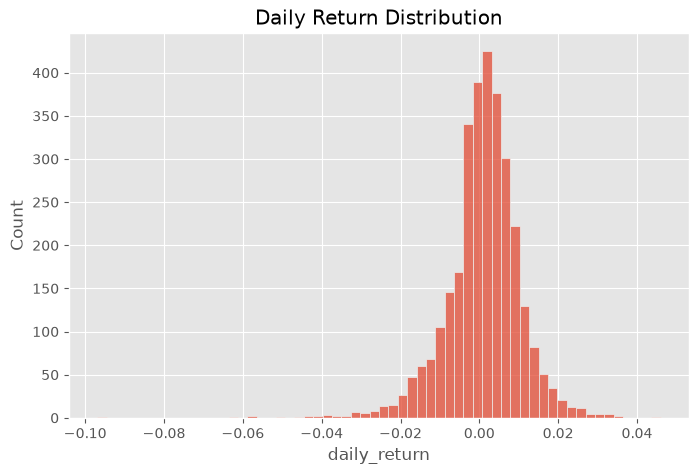

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    funds["hdfc_top_100"]["daily_return"].dropna(),
    bins=60
)

plt.title("Daily Return Distribution")
plt.show()

# Daily Return Chart

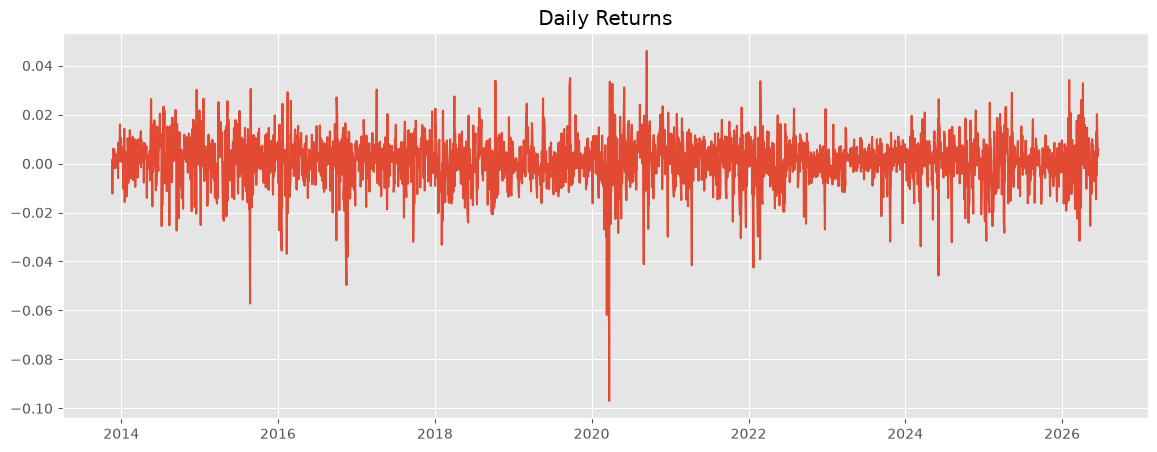

In [5]:
plt.figure(figsize=(14,5))

plt.plot(
    funds["hdfc_top_100"]["date"],
    funds["hdfc_top_100"]["daily_return"]
)

plt.title("Daily Returns")
plt.show()

# Sharpe Ratio

In [6]:
risk_free = 0.065

results = []

for name,df in funds.items():

    returns = df["daily_return"].dropna()

    annual_return = returns.mean()*252

    annual_std = returns.std()*np.sqrt(252)

    sharpe = (annual_return-risk_free)/annual_std

    results.append([name,sharpe])

sharpe_df = pd.DataFrame(
    results,
    columns=["Fund","Sharpe"]
)

sharpe_df = sharpe_df.sort_values(
    "Sharpe",
    ascending=False
)

sharpe_df

c:\Users\its\OneDrive\Desktop\MF_Analytics_Platform\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Fund,Sharpe
1,hdfc_top_100,1.110988
3,kotak_bluechip,0.695097
4,nippon_large_cap,0.572915
0,axis_bluechip,0.265457
5,sbi_bluechip,-0.677508
2,icici_bluechip,NaN


In [7]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

# CAGR Function

In [8]:
def calculate_cagr(df, years):

    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df["date"] >= start_date]

    if len(temp) < 2:
        return np.nan

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    return cagr

# Calculate 1Y , 3Y and 5Y CGAR

In [9]:
cagr_result = []

for name, df in funds.items():

    cagr_1 = calculate_cagr(df, 1)
    cagr_3 = calculate_cagr(df, 3)
    cagr_5 = calculate_cagr(df, 5)

    cagr_result.append([
        name,
        round(cagr_1,2),
        round(cagr_3,2),
        round(cagr_5,2)
    ])

cagr_df = pd.DataFrame(
    cagr_result,
    columns=[
        "Fund",
        "1 Year CAGR",
        "3 Year CAGR",
        "5 Year CAGR"
    ]
)

cagr_df

,Fund,1 Year CAGR,3 Year CAGR,5 Year CAGR
0,axis_bluechip,6.22,7.36,6.54
1,hdfc_top_100,5.16,13.82,15.38
2,icici_bluechip,1.23,10.82,8.32
3,kotak_bluechip,5.45,17.63,18.35
4,nippon_large_cap,1.48,15.03,16.25
5,sbi_bluechip,-1.42,-2.00,-7.36


In [10]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

<Figure size 1000x600 with 0 Axes>

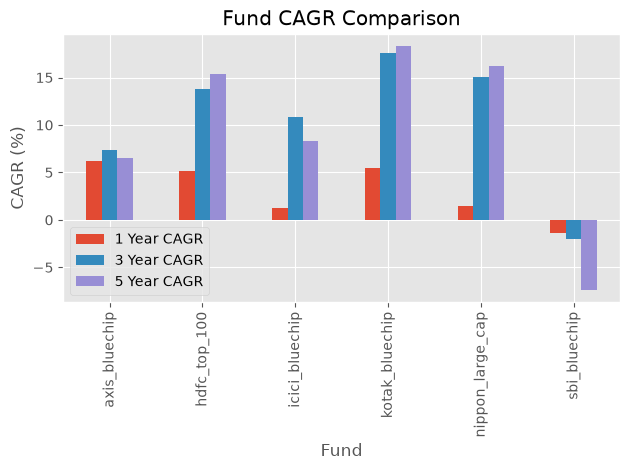

In [11]:
plt.figure(figsize=(10,6))

cagr_df.plot(
    x="Fund",
    y=["1 Year CAGR","3 Year CAGR","5 Year CAGR"],
    kind="bar"
)

plt.title("Fund CAGR Comparison")
plt.ylabel("CAGR (%)")

plt.tight_layout()

plt.show()

# Sortino Ration

In [12]:
risk_free = 0.065

sortino_result=[]

for name,df in funds.items():

    returns=df["daily_return"].dropna()

    annual_return=returns.mean()*252

    downside=returns[returns<0]

    downside_std=downside.std()*np.sqrt(252)

    sortino=(annual_return-risk_free)/downside_std

    sortino_result.append([name,sortino])

sortino_df=pd.DataFrame(
    sortino_result,
    columns=["Fund","Sortino Ratio"]
)

sortino_df=sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
)

sortino_df

,Fund,Sortino Ratio
2,icici_bluechip,inf
0,axis_bluechip,648.528278
1,hdfc_top_100,1.344972
3,kotak_bluechip,0.808853
4,nippon_large_cap,0.710309
5,sbi_bluechip,-0.383674


In [13]:
sortino_df.to_csv("../reports/sortino_ratio.csv",index=False)

# Maximum Drawdown

In [14]:
drawdown=[]

for name,df in funds.items():

    running_max=df["nav"].cummax()

    dd=(df["nav"]/running_max)-1

    max_dd=dd.min()

    drawdown.append([name,max_dd])

drawdown_df=pd.DataFrame(
    drawdown,
    columns=["Fund","Maximum Drawdown"]
)

drawdown_df

,Fund,Maximum Drawdown
0,axis_bluechip,-0.013924
1,hdfc_top_100,-0.402601
2,icici_bluechip,-1.000000
3,kotak_bluechip,-0.334299
4,nippon_large_cap,-0.399608
5,sbi_bluechip,-0.366517


In [15]:
drawdown_df.to_csv("../reports/max_drawdown.csv",index=False)

# Correlation Matrics

In [16]:
returns_df=pd.DataFrame()

for name,df in funds.items():

    returns_df[name]=df["daily_return"]

corr=returns_df.corr()

corr

,axis_bluechip,hdfc_top_100,icici_bluechip,kotak_bluechip,nippon_large_cap,sbi_bluechip
axis_bluechip,1.000000,0.006217,-0.013942,-0.015480,-0.001176,0.004334
hdfc_top_100,0.006217,1.000000,0.241827,-0.003180,-0.016523,0.032066
icici_bluechip,-0.013942,0.241827,1.000000,-0.003817,0.005534,0.013322
kotak_bluechip,-0.015480,-0.003180,-0.003817,1.000000,0.676786,-0.012939
nippon_large_cap,-0.001176,-0.016523,0.005534,0.676786,1.000000,-0.005241
sbi_bluechip,0.004334,0.032066,0.013322,-0.012939,-0.005241,1.000000


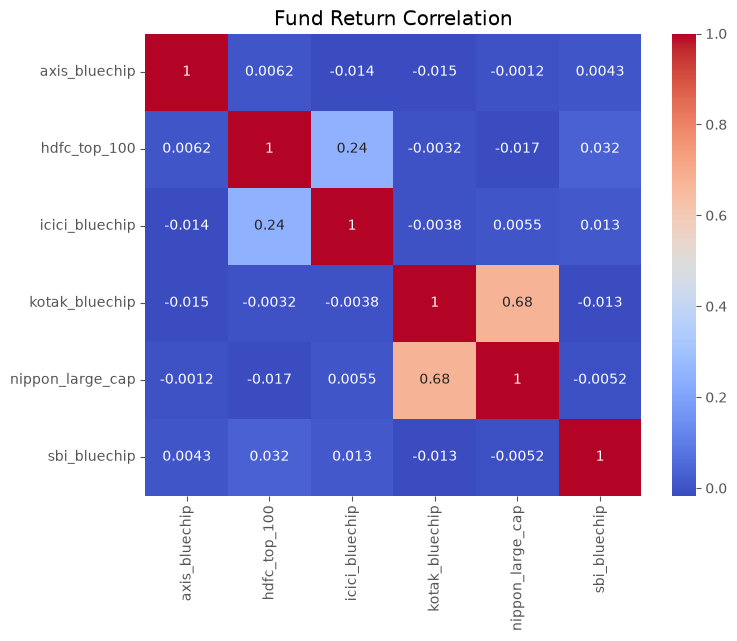

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Fund Return Correlation")

plt.show()

# NAV Comparision

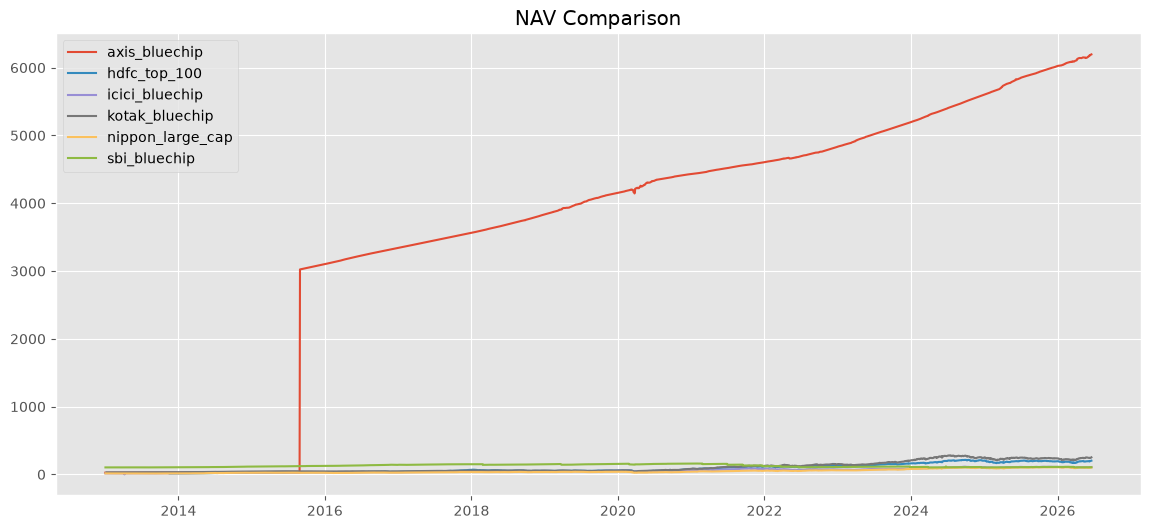

In [18]:
plt.figure(figsize=(14,6))

for name,df in funds.items():

    plt.plot(
        df["date"],
        df["nav"],
        label=name
    )

plt.legend()

plt.title("NAV Comparison")

plt.show()

# Daily Return 

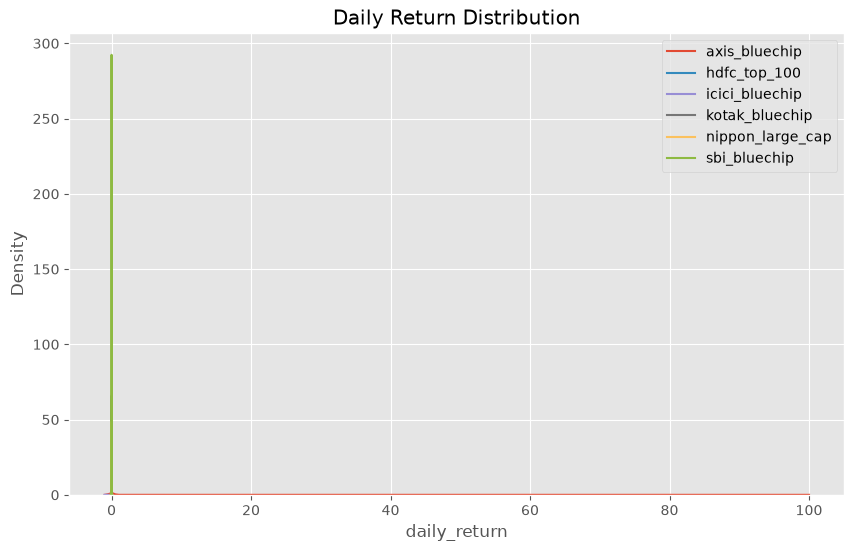

In [19]:
plt.figure(figsize=(10,6))

for name,df in funds.items():

    sns.kdeplot(
        df["daily_return"].dropna(),
        label=name
    )

plt.legend()

plt.title("Daily Return Distribution")

plt.show()

# Fund Ranking

In [20]:
ranking=sharpe_df.merge(
    sortino_df,
    on="Fund"
)

ranking=ranking.merge(
    cagr_df,
    on="Fund"
)

ranking

,Fund,Sharpe,Sortino Ratio,1 Year CAGR,3 Year CAGR,5 Year CAGR
0,hdfc_top_100,1.110988,1.344972,5.16,13.82,15.38
1,kotak_bluechip,0.695097,0.808853,5.45,17.63,18.35
2,nippon_large_cap,0.572915,0.710309,1.48,15.03,16.25
3,axis_bluechip,0.265457,648.528278,6.22,7.36,6.54
4,sbi_bluechip,-0.677508,-0.383674,-1.42,-2.00,-7.36
5,icici_bluechip,NaN,inf,1.23,10.82,8.32


In [21]:
ranking["Score"]=(
ranking["Sharpe"]*0.4+
ranking["Sortino Ratio"]*0.3+
ranking["3 Year CAGR"]*0.3
)

ranking=ranking.sort_values(
"Score",
ascending=False
)

ranking

,Fund,Sharpe,Sortino Ratio,1 Year CAGR,3 Year CAGR,5 Year CAGR,Score
3,axis_bluechip,0.265457,648.528278,6.22,7.36,6.54,196.872666
1,kotak_bluechip,0.695097,0.808853,5.45,17.63,18.35,5.809695
0,hdfc_top_100,1.110988,1.344972,5.16,13.82,15.38,4.993887
2,nippon_large_cap,0.572915,0.710309,1.48,15.03,16.25,4.951259
4,sbi_bluechip,-0.677508,-0.383674,-1.42,-2.00,-7.36,-0.986106
5,icici_bluechip,NaN,inf,1.23,10.82,8.32,NaN


In [22]:
ranking.to_csv(
"../reports/fund_scorecard.csv",
index=False
)

# Best Performing Funds

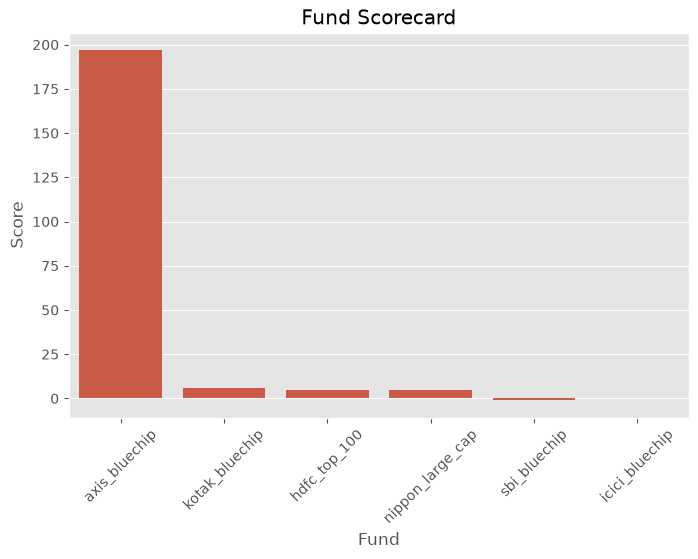

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
data=ranking,
x="Fund",
y="Score"
)

plt.xticks(rotation=45)

plt.title("Fund Scorecard")

plt.show()

# CGAR Comparision

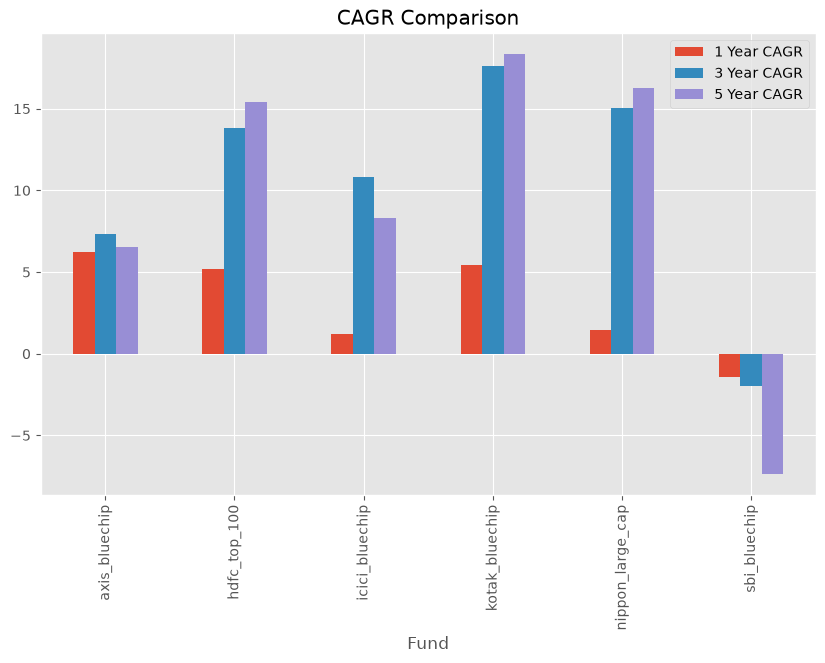

In [24]:
cagr_df.plot(
x="Fund",
y=[
"1 Year CAGR",
"3 Year CAGR",
"5 Year CAGR"
],
kind="bar",
figsize=(10,6)
)

plt.title("CAGR Comparison")

plt.show()

# Sharpe Ratio Comparision

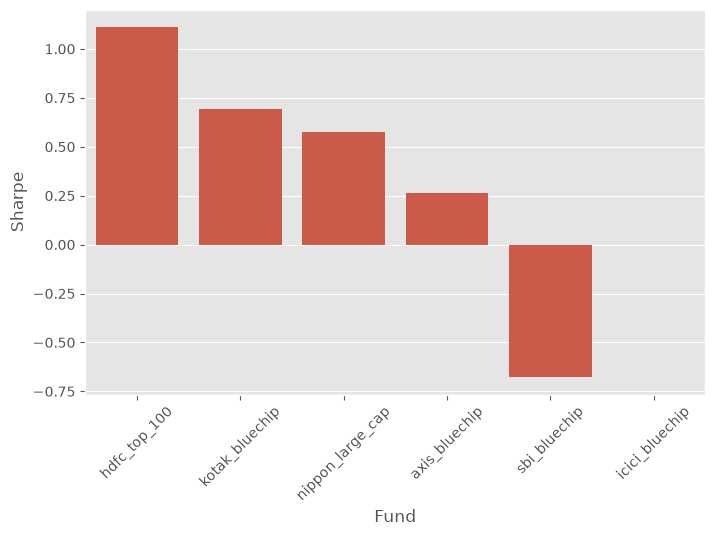

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
data=sharpe_df,
x="Fund",
y="Sharpe"
)

plt.xticks(rotation=45)

plt.show()

# Sortino Ratio Comparision

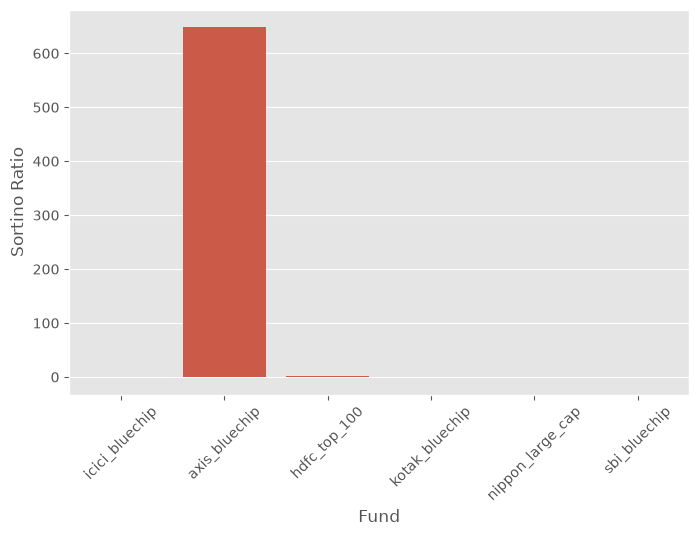

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
data=sortino_df,
x="Fund",
y="Sortino Ratio"
)

plt.xticks(rotation=45)

plt.show()

# Maximum Drawdown Chart

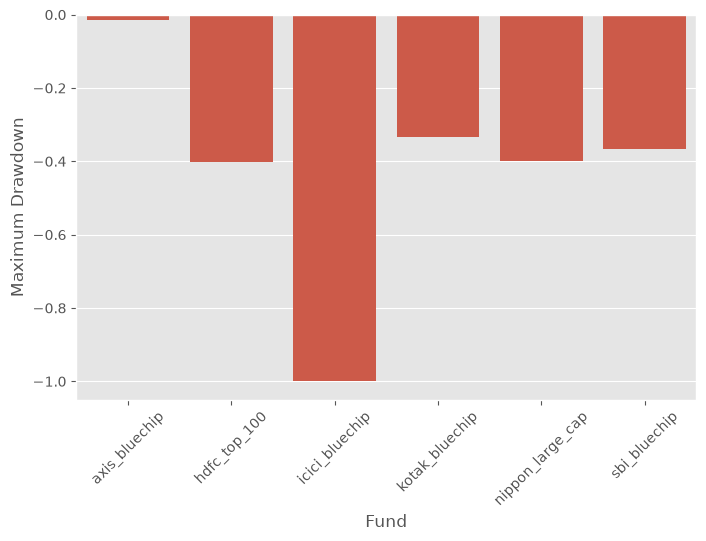

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
data=drawdown_df,
x="Fund",
y="Maximum Drawdown"
)

plt.xticks(rotation=45)

plt.show()